## Deep Learning

### Chapter 7: Evaluating & Improving Neural Network Models

A Neural Network can be inefficient if the problem is the data itself. This inefficiency often stems from issues within the data collection, preparation, or labeling processes. Addressing these data-related challenges is often more impactful than solely focusing on complex model architectures.

*   **Training, Validation, and Testing set**: Data is split into these three parts. The training set is for the model to learn from, the validation set is used to tune the model and avoid overfitting during training, and the testing set provides a final, unbiased evaluation of the model's performance on new data.
*   **Accuracy and Loss**: Accuracy measures how often the model is correct. Loss quantifies the error; the goal is to minimize this value during training to make predictions more precise.
*   **Mislabeled Samples, Noise Features**: Mislabeled samples are incorrect labels that confuse the model. Noise features are irrelevant data points that can mislead the model or make it overfit, hurting its ability to generalize.
*   **Common-Sense Baseline**: This is a simple, non-ML approach that sets a minimum performance bar. If your complex model can't beat it, there's likely an issue.
*   **Data Leakage**: This occurs when your model inadvertently uses information that wouldn't be available in a real-world prediction scenario, leading to overly optimistic performance results.

In [1]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Vectorize 28x28 image to 784 channels and normalize to [0, 1].
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255.0

print("Train Images:", train_images.shape)
print("Test Images:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Images: (60000, 784)
Test Images: (10000, 784)


In [2]:
# Here, we only use 20000 images for demonstration
MNIST_SAMPLE_SIZE = 20000

train_images_demo = train_images[:MNIST_SAMPLE_SIZE]
train_labels_demo = train_labels[:MNIST_SAMPLE_SIZE]

print("Shape train_images_demo:", train_images_demo.shape)
print("Shape train_labels_demo:", train_labels_demo.shape)

Shape train_images_demo: (20000, 784)
Shape train_labels_demo: (20000,)


In [3]:
import numpy as np

# Randomize 784 noise channels
noise_channels = np.random.random((len(train_images_demo), 784)).astype("float32")

# Create 784 channels with only zeros
zero_channels = np.zeros((len(train_images_demo), 784), dtype="float32")

# Concatenate original data to noise_channels with axis=1.
train_images_with_noise_channels = np.concatenate([train_images_demo,
                                                   noise_channels], axis=1)

# Concatenate original data to zero_channels with axis=1.
train_images_with_zeros_channels = np.concatenate([train_images_demo,
                                                   zero_channels], axis=1)

print("Data shape with noise channels:", train_images_with_noise_channels.shape)
print("Data shape with zero channels:", train_images_with_zeros_channels.shape)

Data shape with noise channels: (20000, 1568)
Data shape with zero channels: (20000, 1568)


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model
def train_mnist_model(input_images):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [5]:
# Train the model on the data with noise channels
model_with_noise_channels = train_mnist_model(train_images_with_noise_channels)

history_noise = model_with_noise_channels.fit(train_images_with_noise_channels,
                                              train_labels_demo, epochs=10,
                                              batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6673 - loss: 1.0222 - val_accuracy: 0.8857 - val_loss: 0.4025
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8624 - loss: 0.4270 - val_accuracy: 0.9057 - val_loss: 0.2952
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9020 - loss: 0.2999 - val_accuracy: 0.9337 - val_loss: 0.2293
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9293 - loss: 0.2194 - val_accuracy: 0.9370 - val_loss: 0.1984
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9485 - loss: 0.1621 - val_accuracy: 0.8332 - val_loss: 0.6094
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9598 - loss: 0.1258 - val_accuracy: 0.9425 - val_loss: 0.1921
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9691 - loss: 0.0955 - val_accuracy: 0.9208 - val_loss: 0.2829
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9756 - loss: 0.0759 - val_accu

In [6]:
# Train the model on the data with zero channels
model_with_zeros_channels = train_mnist_model(train_images_with_zeros_channels)

history_zeros = model_with_zeros_channels.fit(train_images_with_zeros_channels,
                                              train_labels_demo, epochs=10,
                                              batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8663 - loss: 0.4409 - val_accuracy: 0.9273 - val_loss: 0.2377
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9476 - loss: 0.1722 - val_accuracy: 0.9560 - val_loss: 0.1512
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9679 - loss: 0.1048 - val_accuracy: 0.9615 - val_loss: 0.1287
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9786 - loss: 0.0700 - val_accuracy: 0.9557 - val_loss: 0.1491
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9597 - val_loss: 0.1434
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9896 - loss: 0.0333 - val_accuracy: 0.9710 - val_loss: 0.1081
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9925 - loss: 0.0233 - val_accuracy: 0.9712 - val_loss: 0.1003
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9958 - loss: 0.0153 - val_accu

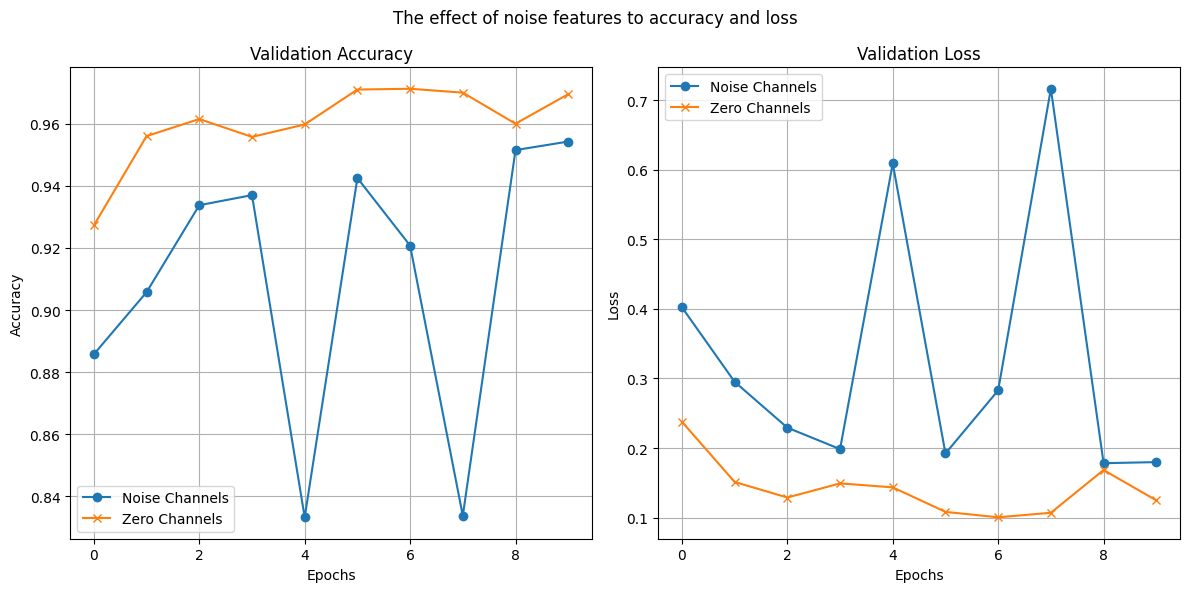

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_noise.history["val_accuracy"], label="Noise Channels", marker='o')
plt.plot(history_zeros.history["val_accuracy"], label="Zero Channels", marker='x')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot validation loss
plt.subplot(1, 2, 2)
plt.plot(history_noise.history["val_loss"], label="Noise Channels", marker='o')
plt.plot(history_zeros.history["val_loss"], label="Zero Channels", marker='x')
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('The effect of noise features to accuracy and loss')
plt.tight_layout()
plt.show()

In [8]:
# Create random labels by shuffling the original labels
random_train_labels = train_labels_demo.copy()
np.random.shuffle(random_train_labels)

# Train model with the random labels
model_random_labels = train_mnist_model(train_images_demo)
history_random_labels = model_random_labels.fit(train_images_demo, random_train_labels,
                                                epochs=12, batch_size=128,
                                                validation_split=0.2, verbose=1)

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1037 - loss: 2.3128 - val_accuracy: 0.0915 - val_loss: 2.3157
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1203 - loss: 2.2982 - val_accuracy: 0.1042 - val_loss: 2.3095
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1324 - loss: 2.2863 - val_accuracy: 0.1082 - val_loss: 2.3212
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1466 - loss: 2.2660 - val_accuracy: 0.1028 - val_loss: 2.3346
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1721 - loss: 2.2375 - val_accuracy: 0.0972 - val_loss: 2.3554
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1938 - loss: 2.1991 - val_accuracy: 0.0953 - val_loss: 2.3672
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2245 - loss: 2.1484 - val_accuracy: 0.0967 - val_loss: 2.4150
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2495 - loss: 2.0921 - val_accu

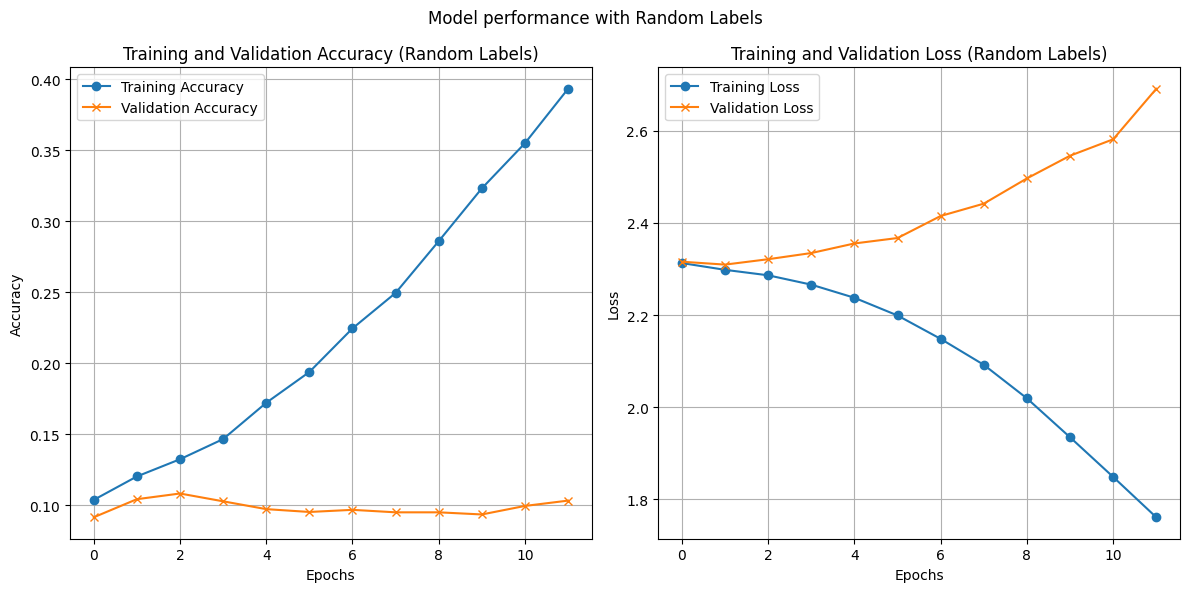

In [9]:
# Plot
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_random_labels.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_random_labels.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title("Training and Validation Accuracy (Random Labels)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_random_labels.history["loss"], label="Training Loss", marker='o')
plt.plot(history_random_labels.history["val_loss"], label="Validation Loss", marker='x')
plt.title("Training and Validation Loss (Random Labels)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model performance with Random Labels')
plt.tight_layout()
plt.show()

Configurable `learning_rate` means that you can adjust how quickly the model learns. A higher learning rate may speed up training but can lead to overshooting the optimal solution, while a lower learning rate may result in more stable convergence but can take longer to train.

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model with learning rates
def train_mnist_model_with_lr(input_images, learning_rate):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
  model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [11]:
# Train with learning rate=1.0
model_lr_1 = train_mnist_model_with_lr(train_images_demo, 1.0)

history_lr_1 = model_lr_1.fit(train_images_demo, train_labels_demo,
                              epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1874 - loss: 116166.4688 - val_accuracy: 0.0993 - val_loss: 3.4087
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1019 - loss: 65.2003 - val_accuracy: 0.0983 - val_loss: 2.6072
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1012 - loss: 8.2622 - val_accuracy: 0.1045 - val_loss: 2.5717
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.0976 - loss: 2.4330 - val_accuracy: 0.0953 - val_loss: 2.7686
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1023 - loss: 2.4456 - val_accuracy: 0.1005 - val_loss: 2.7150
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1023 - loss: 2.4604 - val_accuracy: 0.1045 - val_loss: 2.6827
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1014 - loss: 2.4501 - val_accuracy: 0.0985 - val_loss: 2.6016
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1043 - loss: 2.4442 - va

In [12]:
# Train with learning rate=1e-2
model_lr_1e2 = train_mnist_model_with_lr(train_images_demo, 1e-2)
history_lr_1e2 = model_lr_1e2.fit(train_images_demo, train_labels_demo,
                                  epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8204 - loss: 0.9423 - val_accuracy: 0.9352 - val_loss: 0.2241
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9334 - loss: 0.2260 - val_accuracy: 0.9235 - val_loss: 0.2898
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9559 - loss: 0.1526 - val_accuracy: 0.9358 - val_loss: 0.2621
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9643 - loss: 0.1264 - val_accuracy: 0.9398 - val_loss: 0.2446
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9714 - loss: 0.1035 - val_accuracy: 0.9607 - val_loss: 0.1929
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9765 - loss: 0.0876 - val_accuracy: 0.9578 - val_loss: 0.2039
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9805 - loss: 0.0797 - val_accuracy: 0.9550 - val_loss: 0.2042
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9823 - loss: 0.0732 - val_accu

In [13]:
# Train with learning rate=1e-3
model_lr_1e3 = train_mnist_model_with_lr(train_images_demo, 1e-3)
history_lr_1e3 = model_lr_1e2.fit(train_images_demo, train_labels_demo,
                                  epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9860 - loss: 0.0636 - val_accuracy: 0.9688 - val_loss: 0.2192
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9874 - loss: 0.0544 - val_accuracy: 0.9578 - val_loss: 0.3036
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9877 - loss: 0.0559 - val_accuracy: 0.9645 - val_loss: 0.3044
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9896 - loss: 0.0501 - val_accuracy: 0.9640 - val_loss: 0.3505
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9902 - loss: 0.0459 - val_accuracy: 0.9703 - val_loss: 0.2736
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9902 - loss: 0.0525 - val_accuracy: 0.9647 - val_loss: 0.3876
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9921 - loss: 0.0457 - val_accuracy: 0.9605 - val_loss: 0.4670
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9925 - loss: 0.0422 - val_accu

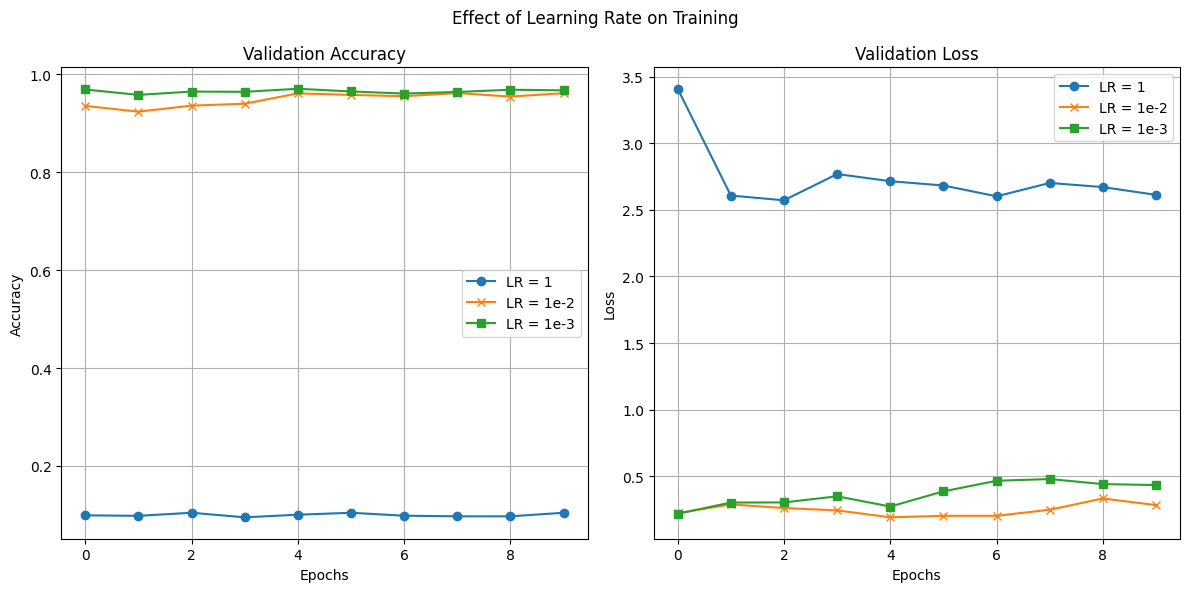

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Validation Accuracy
plt.subplot(1, 2, 1)

plt.plot(history_lr_1.history["val_accuracy"], label="LR = 1", marker='o')
plt.plot(history_lr_1e2.history["val_accuracy"], label="LR = 1e-2", marker='x')
plt.plot(history_lr_1e3.history["val_accuracy"], label="LR = 1e-3", marker='s')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

# Validation Loss
plt.subplot(1, 2, 2)

plt.plot(history_lr_1.history["val_loss"], label="LR = 1", marker='o')
plt.plot(history_lr_1e2.history["val_loss"], label="LR = 1e-2", marker='x')
plt.plot(history_lr_1e3.history["val_loss"], label="LR = 1e-3", marker='s')

plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.suptitle("Effect of Learning Rate on Training")
plt.tight_layout()
plt.show()

**L2 Regularization (Weight Decay):** This technique penalizes large weights in the model, encouraging simpler models and reducing overfitting by adding a term to the loss function proportional to the square of the weight magnitudes.

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Define the mnist model with L2 regularization
def train_mnist_model_regularization(input_images, l2_strength):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_strength))
  hidden_layer2 = layers.Dense(256, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_strength))
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [16]:
# Train the model on the data with l2 regularization
model_with_l2 = train_mnist_model_regularization(train_images_demo, 0.002)

history_l2 = model_with_l2.fit(train_images_demo, train_labels_demo,
                               epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8561 - loss: 1.6208 - val_accuracy: 0.8220 - val_loss: 1.2513
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9326 - loss: 0.7437 - val_accuracy: 0.9323 - val_loss: 0.6170
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9456 - loss: 0.4986 - val_accuracy: 0.9392 - val_loss: 0.4590
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9528 - loss: 0.3920 - val_accuracy: 0.9477 - val_loss: 0.3786
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9576 - loss: 0.3359 - val_accuracy: 0.9438 - val_loss: 0.3553
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9616 - loss: 0.2990 - val_accuracy: 0.9572 - val_loss: 0.3080
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9641 - loss: 0.2740 - val_accuracy: 0.9592 - val_loss: 0.2926
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9666 - loss: 0.2576 - val_accu

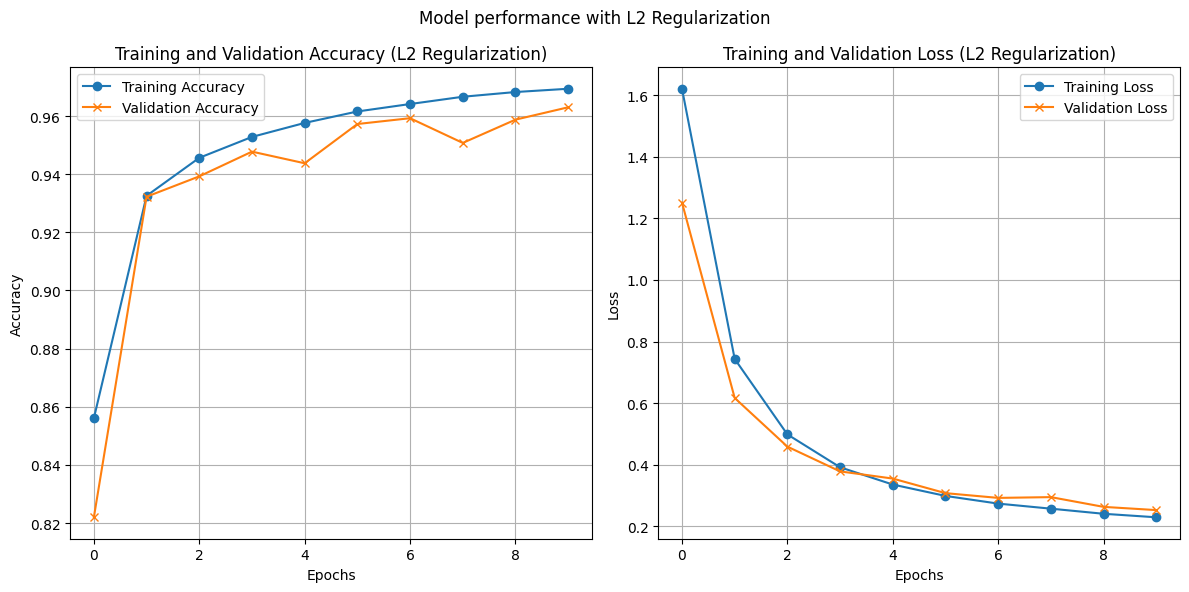

In [17]:
# Plot
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_l2.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_l2.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title("Training and Validation Accuracy (L2 Regularization)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_l2.history["loss"], label="Training Loss", marker='o')
plt.plot(history_l2.history["val_loss"], label="Validation Loss", marker='x')
plt.title("Training and Validation Loss (L2 Regularization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model performance with L2 Regularization')
plt.tight_layout()
plt.show()

**Dropout:** During training, Dropout randomly sets a fraction of neuron outputs to zero at each update. This prevents neurons from becoming too dependent on each other, forcing the network to learn more robust features and improving generalization by acting as an ensemble of smaller networks.

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the mnist model with Dropout
def train_mnist_model_with_dropout(input_images, dropout_rate):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  dropout_layer1 = layers.Dropout(dropout_rate)
  hidden_layer2 = layers.Dense(256, activation="relu")
  dropout_layer2 = layers.Dropout(dropout_rate)
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1, dropout_layer1,
                            hidden_layer2, dropout_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [19]:
# Train the model with Dropout
dropout_rate = 0.5
model_with_dropout = train_mnist_model_with_dropout(train_images_demo, dropout_rate)

history_dropout = model_with_dropout.fit(train_images_demo, train_labels_demo,
                                         epochs=20, batch_size=128,
                                         validation_split=0.2, verbose=1)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7976 - loss: 0.6439 - val_accuracy: 0.9233 - val_loss: 0.2600
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9120 - loss: 0.2991 - val_accuracy: 0.9427 - val_loss: 0.1816
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9332 - loss: 0.2238 - val_accuracy: 0.9597 - val_loss: 0.1407
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9471 - loss: 0.1799 - val_accuracy: 0.9630 - val_loss: 0.1278
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9558 - loss: 0.1514 - val_accuracy: 0.9643 - val_loss: 0.1243
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9599 - loss: 0.1297 - val_accuracy: 0.9645 - val_loss: 0.1196
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9647 - loss: 0.1137 - val_accuracy: 0.9685 - val_loss: 0.1140
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9669 - loss: 0.1056 - val_accu

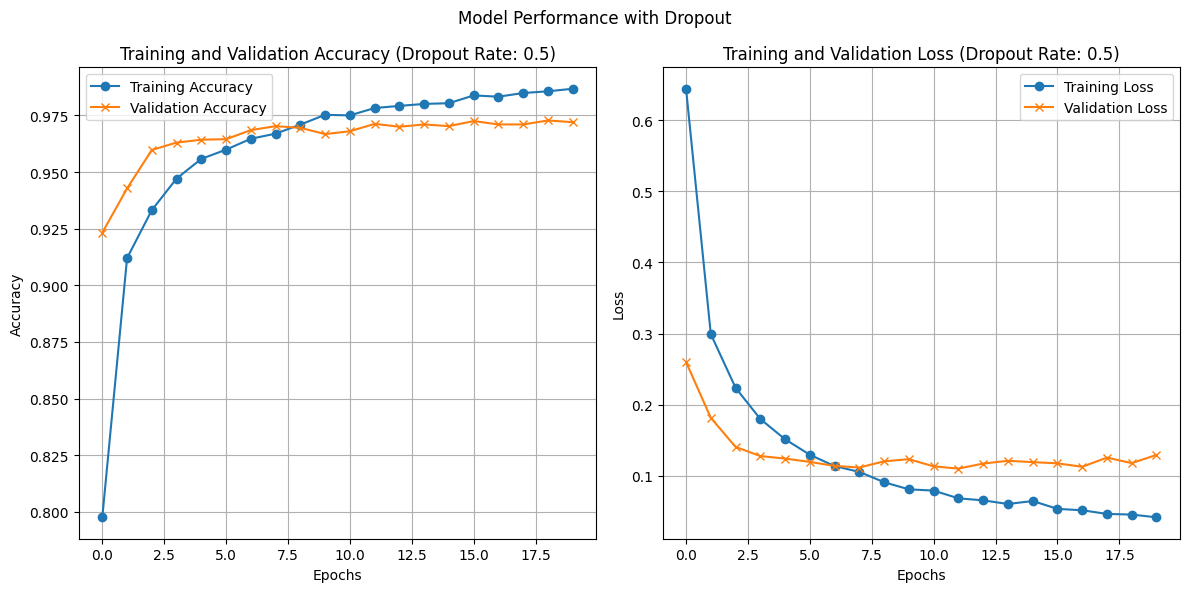

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy with Dropout
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_dropout.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.title(f"Training and Validation Accuracy (Dropout Rate: {dropout_rate})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss with Dropout
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history["loss"], label="Training Loss", marker='o')
plt.plot(history_dropout.history["val_loss"], label="Validation Loss", marker='x')
plt.title(f"Training and Validation Loss (Dropout Rate: {dropout_rate})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model Performance with Dropout')
plt.tight_layout()
plt.show()

**Early Stopping:** This is a form of regularization where training is halted when the model's performance on a validation set stops improving for a specified number of epochs. It prevents overfitting by ensuring the model doesn't continue to learn noise from the training data after it has generalized well.

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Define the mnist model with Early Stopping
def train_mnist_model_with_early_stopping(input_images, patience):
  input_layer = layers.Input(shape=(input_images.shape[1],))
  hidden_layer1 = layers.Dense(512, activation="relu")
  hidden_layer2 = layers.Dense(256, activation="relu")
  output_layer = layers.Dense(10, activation="softmax")

  model = keras.Sequential([input_layer, hidden_layer1,
                            hidden_layer2, output_layer])

  model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

  # Define Early Stopping callback
  early_stopping_callback = EarlyStopping(monitor='val_loss', patience=patience,
                                          restore_best_weights=True, verbose=1)

  history = model.fit(train_images_demo, train_labels_demo,
                      epochs=50, batch_size=128, validation_split=0.2,
                      callbacks=[early_stopping_callback], verbose=1)

  # Get the epoch at which training stopped
  if early_stopping_callback.stopped_epoch > 0:
    stopped_epoch = early_stopping_callback.stopped_epoch
  else:
    stopped_epoch = history.epoch[-1] + 1

  return model, stopped_epoch, history

In [22]:
# Train the model with Early Stopping
patience_value = 5
model_with_early_stopping, stopped_epoch, history_early_stopping = train_mnist_model_with_early_stopping(train_images_demo, patience_value)

print(f"Training stopped at epoch: {stopped_epoch}")

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8633 - loss: 0.4427 - val_accuracy: 0.9455 - val_loss: 0.1913
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9492 - loss: 0.1732 - val_accuracy: 0.9595 - val_loss: 0.1437
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9676 - loss: 0.1077 - val_accuracy: 0.9615 - val_loss: 0.1336
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9790 - loss: 0.0714 - val_accuracy: 0.9628 - val_loss: 0.1318
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9858 - loss: 0.0474 - val_accuracy: 0.9610 - val_loss: 0.1342
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9905 - loss: 0.0317 - val_accuracy: 0.9650 - val_loss: 0.1299
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9949 - loss: 0.0196 - val_accuracy: 0.9672 - val_loss: 0.1195
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9952 - loss: 0.0155 - val_accu

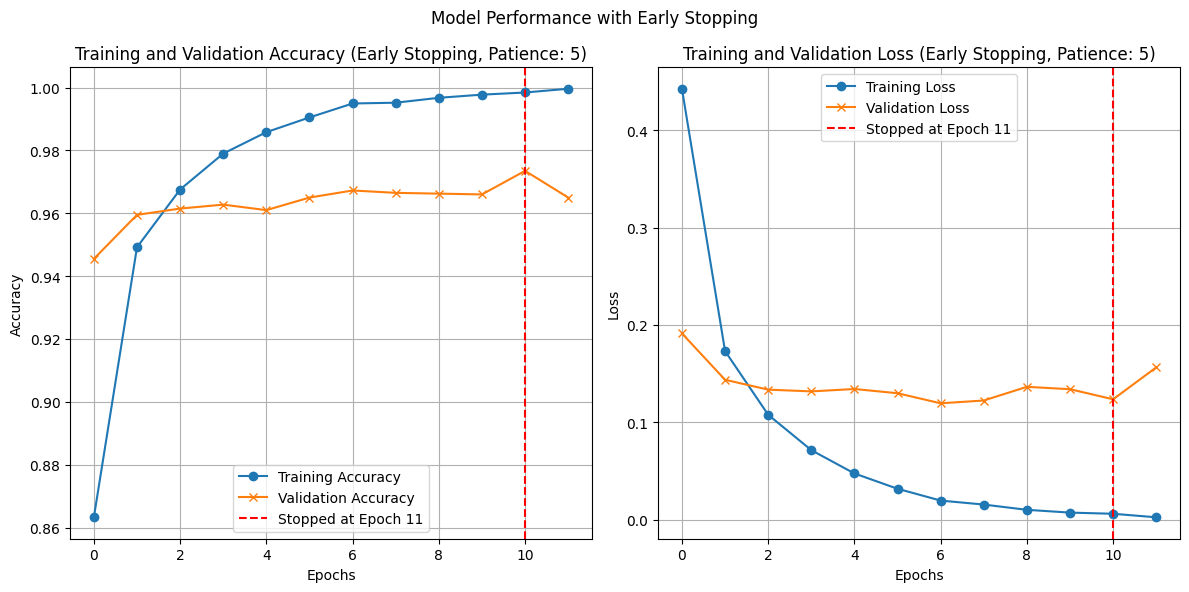

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy with Early Stopping
plt.subplot(1, 2, 1)
plt.plot(history_early_stopping.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history_early_stopping.history["val_accuracy"], label="Validation Accuracy", marker='x')
plt.axvline(x=stopped_epoch - 1, color='r', linestyle='--', label=f'Stopped at Epoch {stopped_epoch}')
plt.title(f"Training and Validation Accuracy (Early Stopping, Patience: {patience_value})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot training and validation loss with Early Stopping
plt.subplot(1, 2, 2)
plt.plot(history_early_stopping.history["loss"], label="Training Loss", marker='o')
plt.plot(history_early_stopping.history["val_loss"], label="Validation Loss", marker='x')
plt.axvline(x=stopped_epoch - 1, color='r', linestyle='--', label=f'Stopped at Epoch {stopped_epoch}')
plt.title(f"Training and Validation Loss (Early Stopping, Patience: {patience_value})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle('Model Performance with Early Stopping')
plt.tight_layout()
plt.show()